In [61]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [93]:
df = pd.read_csv("Amazon Sale Time Series.csv")

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            84 non-null     object 
 1   Amount          84 non-null     float64
 2   day_of_week     84 non-null     int64  
 3   is_weekend      84 non-null     int64  
 4   lag_1           84 non-null     float64
 5   lag_7           84 non-null     float64
 6   rolling_3_mean  84 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 4.7+ KB


In [95]:
# Set Date column format
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

In [96]:
# Setting correct data types
df = df.convert_dtypes()

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            84 non-null     datetime64[ns]
 1   Amount          84 non-null     Float64       
 2   day_of_week     84 non-null     Int64         
 3   is_weekend      84 non-null     Int64         
 4   lag_1           84 non-null     Float64       
 5   lag_7           84 non-null     Float64       
 6   rolling_3_mean  84 non-null     Float64       
dtypes: Float64(4), Int64(2), datetime64[ns](1)
memory usage: 5.2 KB


In [98]:
df.head()

,Date,Amount,day_of_week,is_weekend,lag_1,lag_7,rolling_3_mean
0,2022-04-07,975405.253782,3,0,940816.844296,107521.009743,977207.826185
1,2022-04-08,1078823.500649,4,0,975405.253782,935524.516916,998348.532909
2,2022-04-09,1031096.650734,5,1,1078823.500649,977310.287173,1028441.801722
3,2022-04-10,1127768.467687,6,1,1031096.650734,1075972.137173,1079229.53969
4,2022-04-11,1015713.747087,0,0,1127768.467687,941079.340734,1058192.955169


In [ ]:
df = df.set_index('Date')

In [79]:
y = df['Amount']
x = df.drop(['Amount'], axis=1)

In [87]:
test_size = int(len(x) * 0.2)
x_train, x_test = x.iloc[:-test_size], x.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

In [88]:
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

In [89]:
y_pred = model.predict(x_test)

In [90]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [91]:
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 55397.47
Mean Squared Error: 9298567246.75
Root Mean Squared Error: 96429.08
R2 Score: 0.25


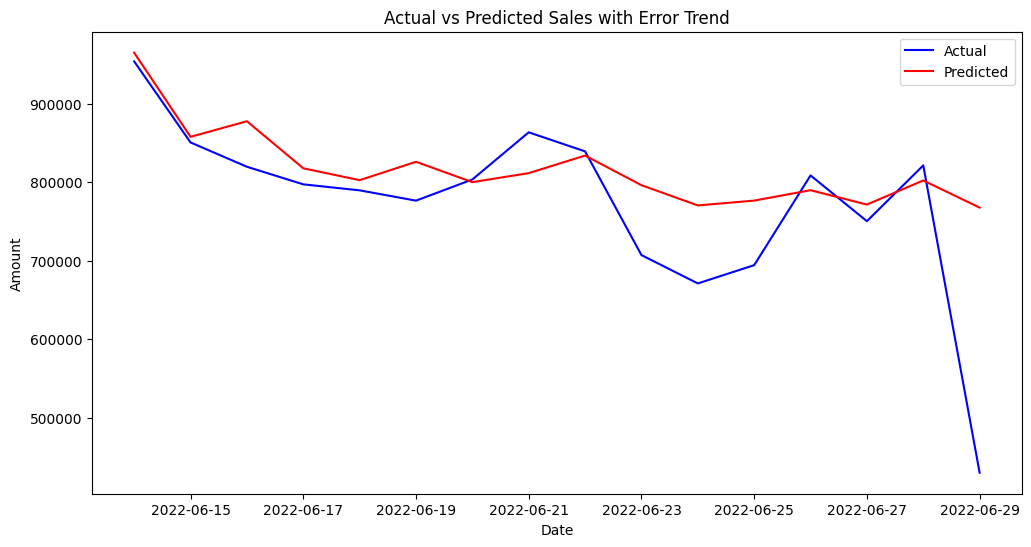

In [92]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted', color='red')

plt.title('Actual vs Predicted Sales with Error Trend')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.show()